### Read the SNOWPACK MLD4 & TKG4 WY2020-WY2025 Simulations, SWE Figures

created by Cassie Lumbrazo\
last updated: June 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/mld4'

## Put Some JIF Data info a simple dataframe to plot later (SWE this time)

In [3]:
# SWE DATAFRAMES
df_field_swe_tkg4 = pd.DataFrame({
    'date': ['2024-06-07', '2024-06-15'],
    'site': ['tkg4', 'tkg4'],
    'swe_cm': [313, 343],
    # convert to mm 
    'swe_mm': [3130, 3430],
})

df_field_swe_tkg4['date'] = pd.to_datetime(df_field_swe_tkg4['date'])
df_field_swe_tkg4

df_field_swe_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'swe_cm': [299, 313],
    'swe_mm': [2990, 3130],
})

df_field_swe_mld4['date'] = pd.to_datetime(df_field_swe_mld4['date'])
df_field_swe_mld4


,date,site,swe_cm,swe_mm
0,2024-06-11,mld4,299,2990
1,2024-06-18,mld4,313,3130


In [4]:
# SNOW DEPTH DATAFRAMES
df_field_depth_tkg4 = pd.DataFrame({
    'date': ['2024-06-15'],
    'site': ['tkg4'],
    'core_depth_cm': [642.5], # this was 800, but it got confusing with the code below, so keeping it the core depth meaning snow-firn transition depth
    # 'snow_firm_transition_depth_cm': [642.5]
})

df_field_depth_tkg4['date'] = pd.to_datetime(df_field_depth_tkg4['date'])
df_field_depth_tkg4


df_field_depth_mld4 = pd.DataFrame({
    'date': ['2024-06-11', '2024-06-18'],
    'site': ['mld4', 'mld4'],
    'core_depth_cm': [678.5, 657]
})

df_field_depth_mld4['date'] = pd.to_datetime(df_field_depth_mld4['date'])
df_field_depth_mld4

,date,site,core_depth_cm
0,2024-06-11,mld4,678.5
1,2024-06-18,mld4,657.0


# Open Data and Model Simulations

## Function for Reading SMET Files 

In [5]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

## Open SNOWPACK SMet Output for WY2020-WY2025

In [6]:
ds_snowpack_mld4, header = read_smet("/home/cassie/python/models/run_snowpack/sites/mld4/output/hrrrak_mld4_WY2020-WY2025_heatflux_soiltemp_zero.smet")
ds_snowpack_tkg4, header = read_smet("/home/cassie/python/models/run_snowpack/sites/tkg4/output/hrrrak_tkg4_WY2020-WY2025_heatflux_soiltemp_zero.smet")

/tmp/ipykernel_3796485/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_3796485/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Text(0, 0.5, 'snow depth (cm)')

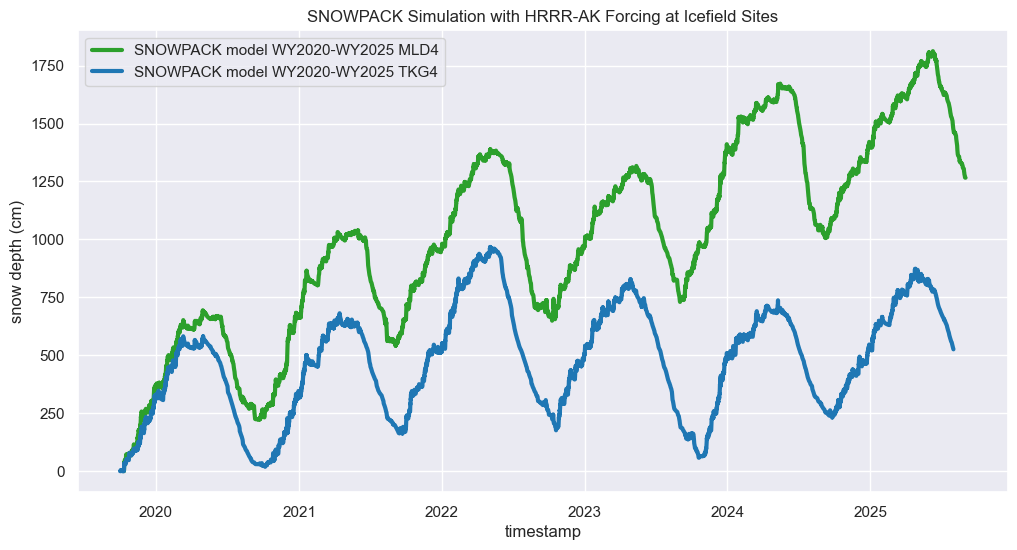

In [7]:
ds_snowpack_mld4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025 MLD4', linewidth = 3, color='tab:green')
ds_snowpack_tkg4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025 TKG4', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at Icefield Sites')
plt.legend()

plt.ylabel('snow depth (cm)')

Text(0, 0.5, 'snow depth (cm)')

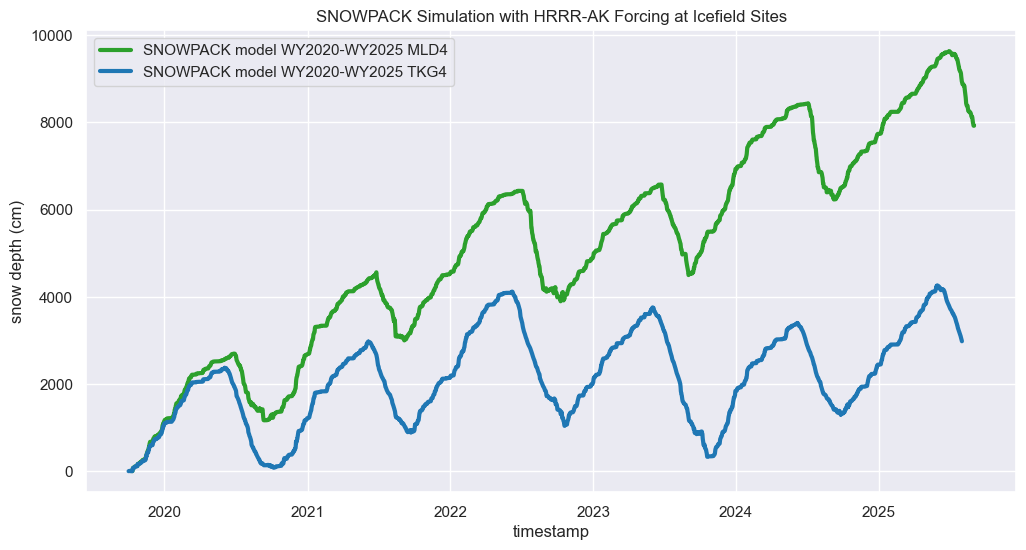

In [8]:
ds_snowpack_mld4.SWE.plot(label = 'SNOWPACK model WY2020-WY2025 MLD4', linewidth = 3, color='tab:green')
ds_snowpack_tkg4.SWE.plot(label = 'SNOWPACK model WY2020-WY2025 TKG4', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at Icefield Sites')
plt.legend()

plt.ylabel('snow depth (cm)')

In [11]:
# what is the modeled snow depth on June 15, 2024 in each simulation?
snow_depth_on_ob1 = ds_snowpack_mld4.HS_mod.sel(timestamp=df_field_depth_mld4['date'].iloc[0], method='nearest').values
snow_depth_on_ob2 = ds_snowpack_mld4.HS_mod.sel(timestamp=df_field_depth_mld4['date'].iloc[1], method='nearest').values

# print the value for the snow depth on observation date 
print(f"Modeled snow depth on obs1: {snow_depth_on_ob1:.2f} cm")
print(f"Modeled snow depth on obs2: {snow_depth_on_ob2:.2f} cm")

# print the value for the firn-snow transiation depth on June 15, 2024 in df_field_depth_mld4
print(f"Field observation of snow-firm transition depth on obs1: {df_field_depth_mld4['core_depth_cm'].iloc[0]:.2f} cm")
print(f"Field observation of snow-firm transition depth on obs2: {df_field_depth_mld4['core_depth_cm'].iloc[1]:.2f} cm")

Modeled snow depth on obs1: 1641.72 cm
Modeled snow depth on obs2: 1630.70 cm
Field observation of snow-firm transition depth on obs1: 678.50 cm
Field observation of snow-firm transition depth on obs2: 657.00 cm


# Remove the lead up to WY2024

Text(0.5, 1.0, 'SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

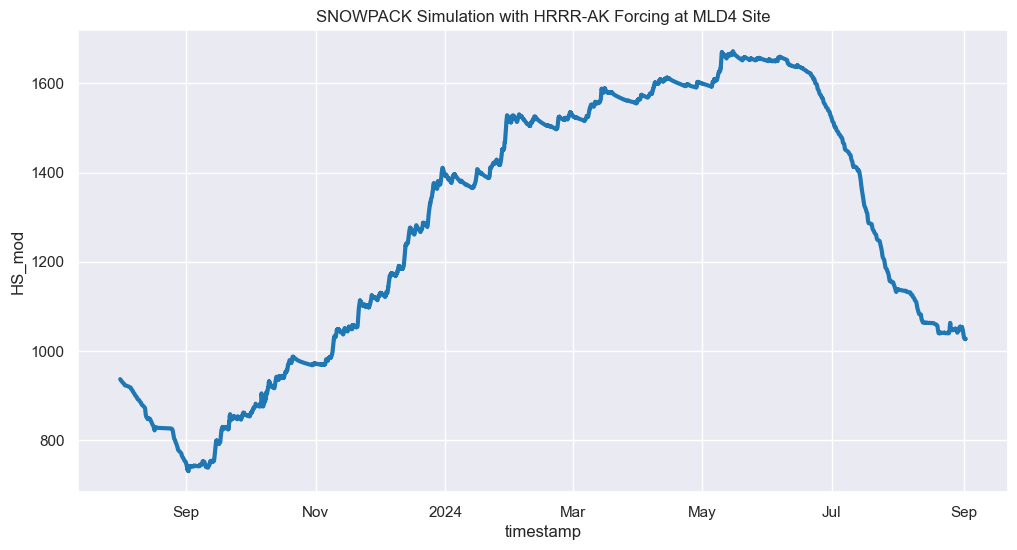

In [13]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack_mld4.HS_mod.copy(deep=True)
# now, only keep the dates between 2023-09-01 and 2024-09-01
hs_model_ds = hs_model_ds.sel(timestamp=slice('2023-08-01', '2024-09-01'))
hs_model_ds.plot(label = 'SNOWPACK model WY2024', linewidth = 3, color='tab:blue')

plt.title('SNOWPACK Simulation with HRRR-AK Forcing at MLD4 Site')

In [14]:
# print the minimum value in the timeseries 
print(f"Minimum snow depth in WY2024: {hs_model_ds.min().values:.2f} cm")


Minimum snow depth in WY2024: 730.36 cm


Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

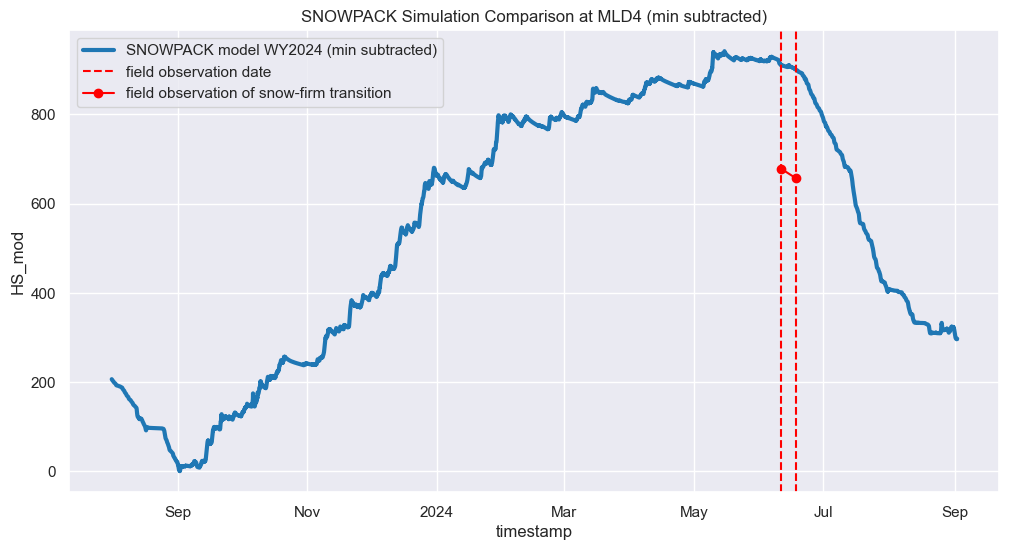

In [16]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK model WY2024 (min subtracted)', linewidth = 3, color='tab:blue')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_depth_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_depth_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_depth_mld4['date'], df_field_depth_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend()
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

NameError: name 'ds_snowpack_WY2024' is not defined

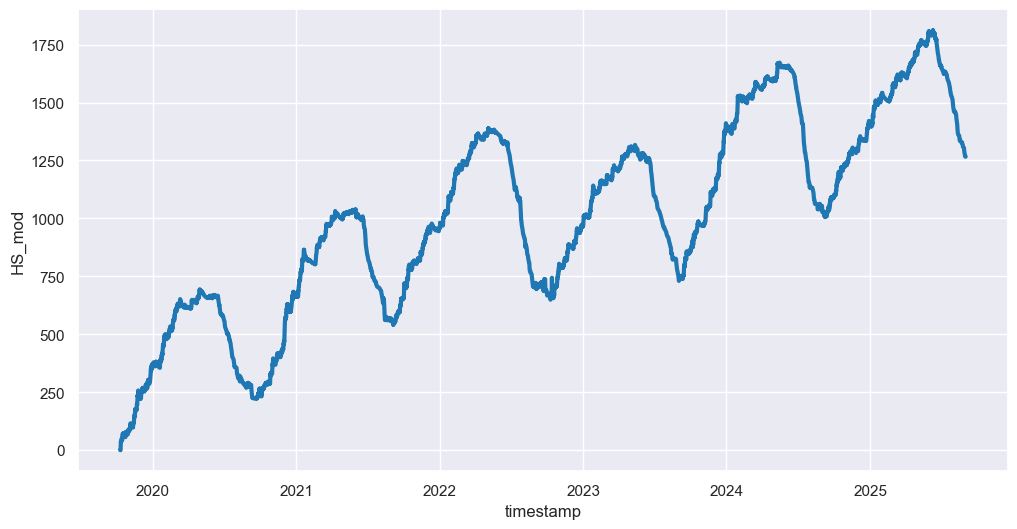

In [18]:
# and plot ds_snowpack_mld and ds_snowpack_2 together for comparison
ds_snowpack_mld4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')
ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
# plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
# plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
# plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm_fixed'], marker='o', color='red', label='field observation of snow-firm transition')

plt.title('SNOWPACK Simulation Comparison at MLD4')

# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.ylabel('snow depth (cm)')


In [19]:
# cut ds_snowpack_WY2024 to 2024-09-01
ds_snowpack_WY2024_cut = ds_snowpack_WY2024.sel(timestamp=slice('2023-08-01', '2024-09-01'))

NameError: name 'ds_snowpack_WY2024' is not defined

Text(0.5, 1.0, 'SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

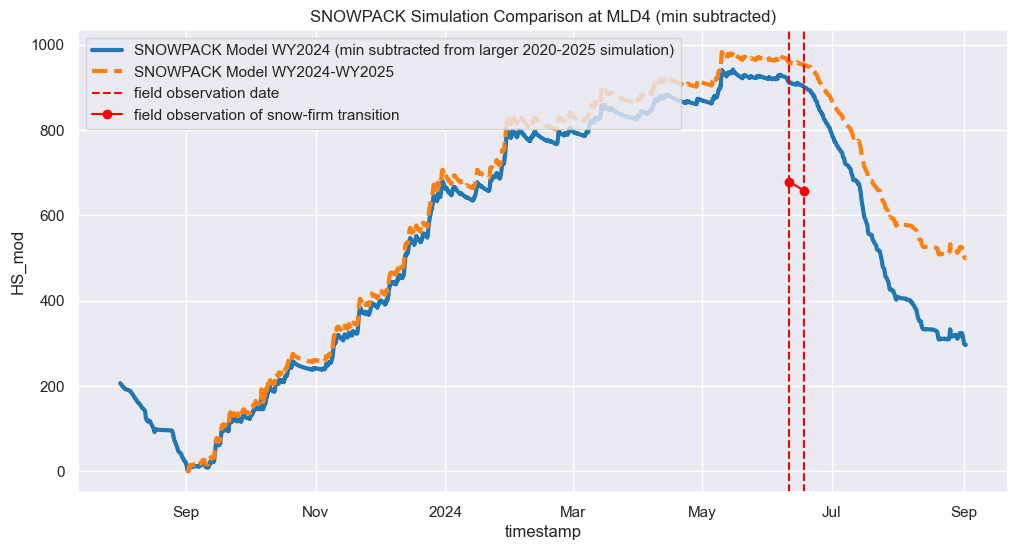

In [ ]:
# now, subtract the entire dataset from the minimum value in the dataset 
hs_model_ds = hs_model_ds - hs_model_ds.min()
hs_model_ds.plot(label = 'SNOWPACK Model WY2024 (min subtracted from larger 2020-2025 simulation)', linewidth = 3, color='tab:blue')
# ds_snowpack_WY2024.HS_mod.plot(label = 'SNOWPACK model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')
ds_snowpack_WY2024_cut.HS_mod.plot(label = 'SNOWPACK Model WY2024-WY2025', linewidth = 3, color='tab:orange', linestyle='--')

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
plt.plot(df_field_mld4['date'], df_field_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firm transition')
plt.legend(loc='upper left')
plt.title('SNOWPACK Simulation Comparison at MLD4 (min subtracted)')

# Deliverable Figures

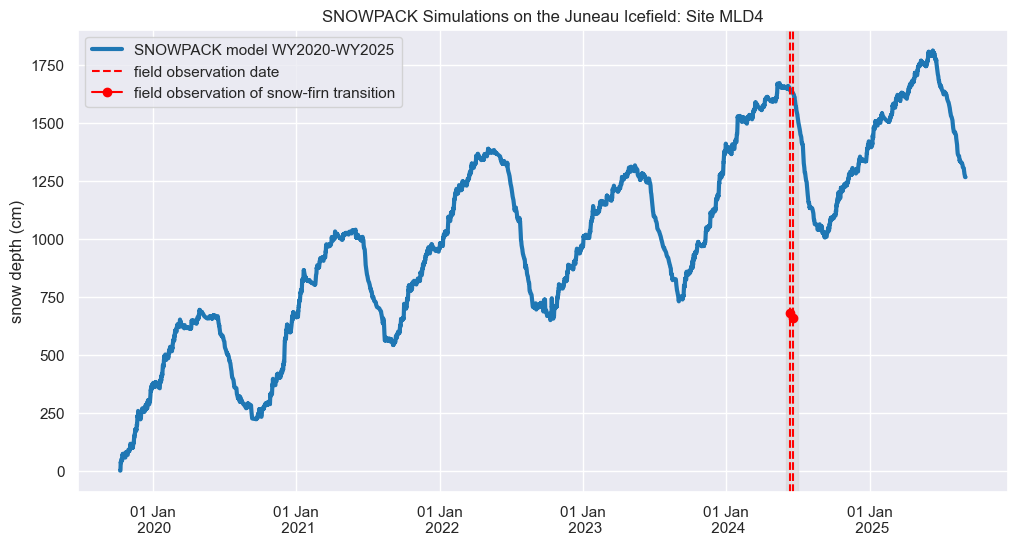

In [22]:
# and plot ds_snowpack and ds_snowpack_2 together for comparison
ds_snowpack_mld4.HS_mod.plot(label = 'SNOWPACK model WY2020-WY2025', linewidth = 3, color='tab:blue')

# highlight the space between June 1 and July 1 in light grey fill
plt.axvspan('2024-06-01', '2024-07-01', color='lightgrey', alpha=0.5)

# add a vertical line at June 15, 2024 to indicate the date of the field observation
plt.axvline(df_field_depth_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_depth_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df snow-firm 
# plt.plot(df_field_depth_mld4['date'], df_field_depth_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firn transition')
plt.plot(df_field_depth_mld4['date'], df_field_depth_mld4['core_depth_cm'], marker='o', color='red', label='field observation of snow-firn transition')


# show the legend in the reverse order 
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::1], labels[::1])


plt.title('SNOWPACK Simulations on the Juneau Icefield: Site MLD4')
# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow depth (cm)')
plt.show()

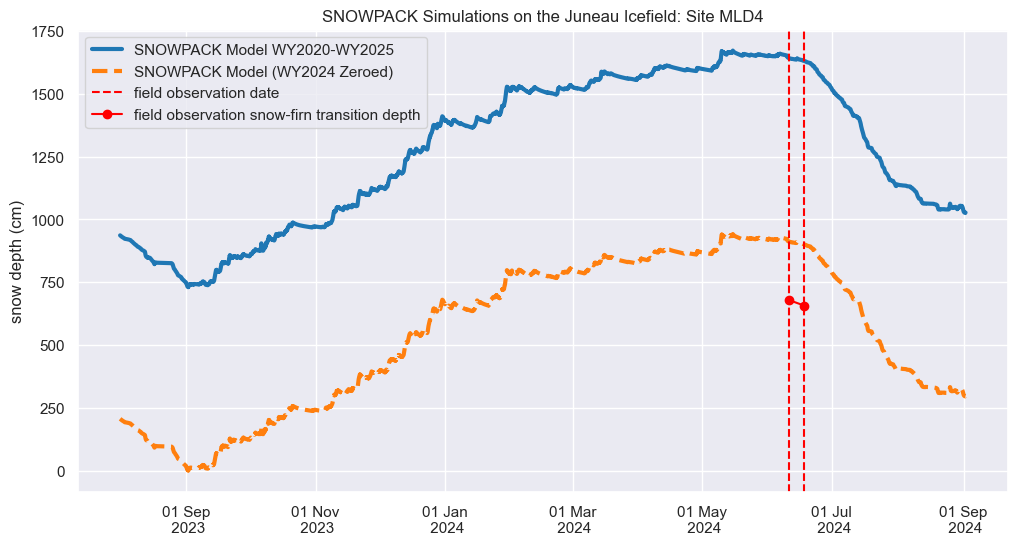

In [24]:
# we want to focus on WY2024
# so let's remove all the data before 

hs_model_ds = ds_snowpack_mld4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

# plot a zeroed-out WY2024 line so the minimum snow depth starts at zero
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

# add vertical lines at the field observation dates
plt.axvline(df_field_depth_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
plt.axvline(df_field_depth_mld4['date'].iloc[1], color='red', linestyle='--', label=None)

# plot df core depth 
plt.plot(df_field_depth_mld4['date'], df_field_depth_mld4['core_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

plt.legend(loc='upper left')

plt.title('SNOWPACK Simulations on the Juneau Icefield: Site MLD4')
# add month into the x-axis
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))   
plt.xlabel('')
plt.ylabel('snow depth (cm)')
plt.show()

## Subplot with snow depth and swe together

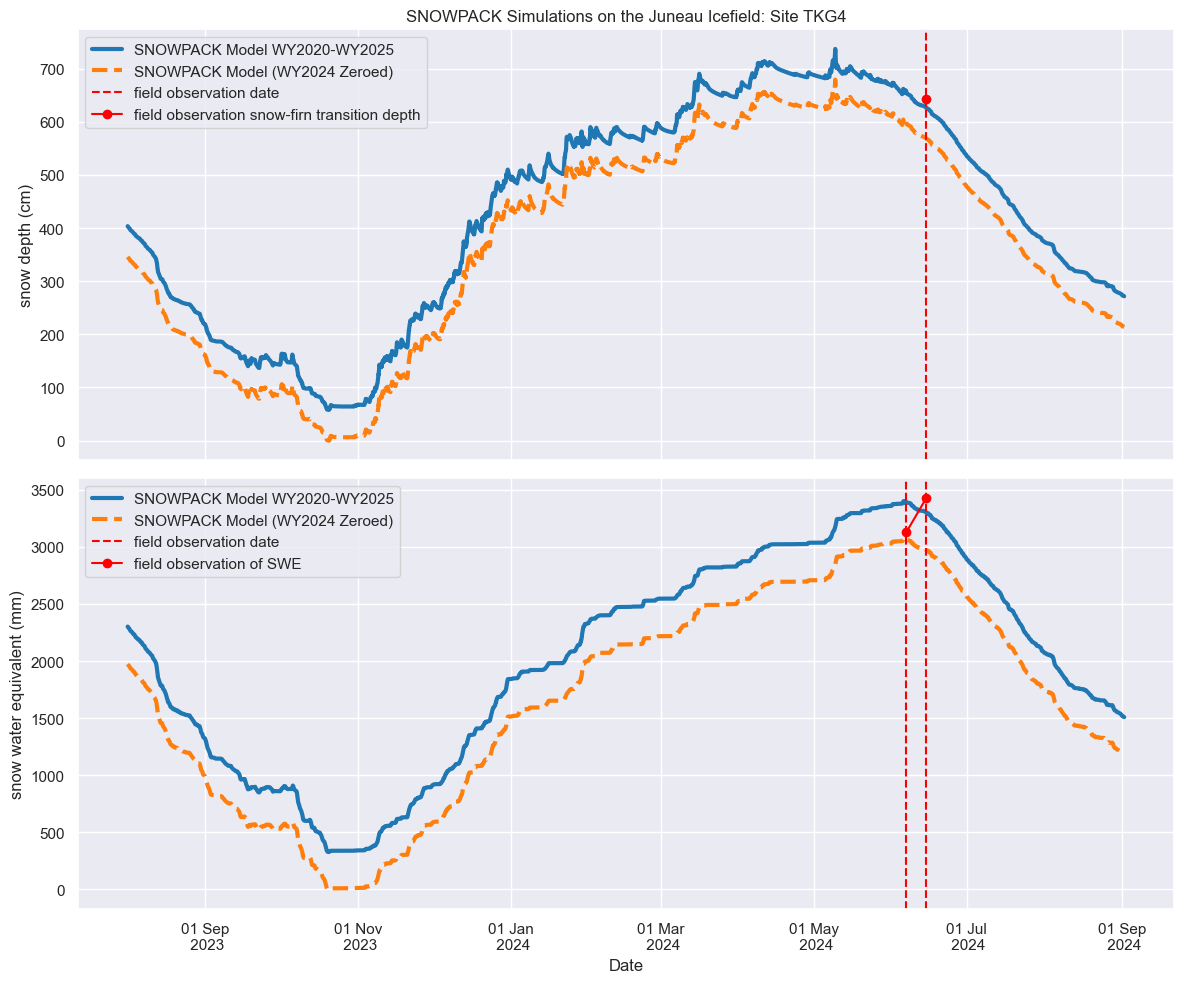

In [25]:
# combined subplot of snow depth and SWE for WY2024
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# top: snow depth
hs_model_ds = ds_snowpack_tkg4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_ds.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')
hs_model_zeroed.plot(ax=axes[0], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_depth_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
# axes[0].axvline(df_field_depth_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_depth_tkg4['date'], df_field_depth_tkg4['core_depth_cm'], marker='o', color='red', label='field observation snow-firn transition depth')

axes[0].legend(loc='upper left')
axes[0].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[0].set_xlabel('')
axes[0].set_ylabel('snow depth (cm)')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: SWE
swe_model_ds = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_model_ds.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025', linewidth=3, color='tab:blue')

swe_model_zeroed = swe_model_ds - swe_model_ds.min(dim='timestamp')
swe_model_zeroed.plot(ax=axes[1], label='SNOWPACK Model (WY2024 Zeroed)', linewidth=3, color='tab:orange', linestyle='--')

# now add the SWE observations from df_field_swe_tkg4
axes[1].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', label='field observation of SWE')


axes[1].legend(loc='upper left')
# axes[1].set_title('SNOWPACK Simulations on the Juneau Icefield: Site TKG4')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')

plt.tight_layout()
plt.show()

# Plot TKG4 and MLD4 Together 

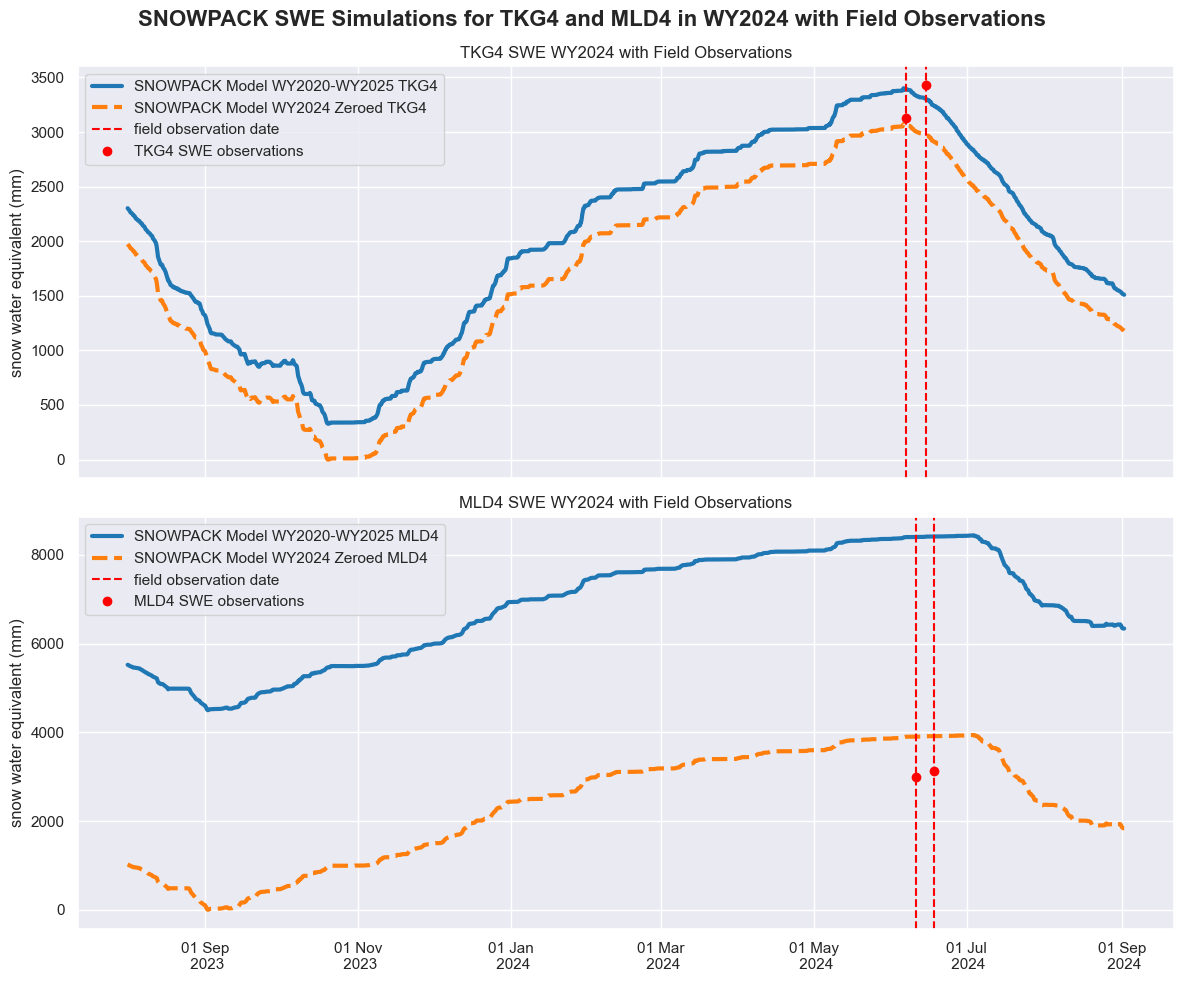

In [26]:
# combined subplot of SWE for TKG4 (top) and MLD4 (bottom) for WY2024
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# top: TKG4 SWE
swe_tkg4 = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_tkg4.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025 TKG4', linewidth=3, color='tab:blue')

swe_tkg4_zeroed = swe_tkg4 - swe_tkg4.min(dim='timestamp')
swe_tkg4_zeroed.plot(ax=axes[0], label='SNOWPACK Model WY2024 Zeroed TKG4', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[0].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', linestyle='', label='TKG4 SWE observations')

axes[0].legend(loc='upper left')
axes[0].set_title('TKG4 SWE WY2024 with Field Observations')
axes[0].set_ylabel('snow water equivalent (mm)')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: MLD4 SWE
swe_mld4 = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_mld4.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025 MLD4', linewidth=3, color='tab:blue')

swe_mld4_zeroed = swe_mld4 - swe_mld4.min(dim='timestamp')
swe_mld4_zeroed.plot(ax=axes[1], label='SNOWPACK Model WY2024 Zeroed MLD4', linewidth=3, color='tab:orange', linestyle='--')

axes[1].axvline(df_field_swe_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_mld4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_mld4['date'], df_field_swe_mld4['swe_mm'], marker='o', color='red', linestyle='', label='MLD4 SWE observations')

axes[1].legend(loc='upper left')
axes[1].set_title('MLD4 SWE WY2024 with Field Observations')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    
plt.suptitle('SNOWPACK SWE Simulations for TKG4 and MLD4 in WY2024 with Field Observations', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


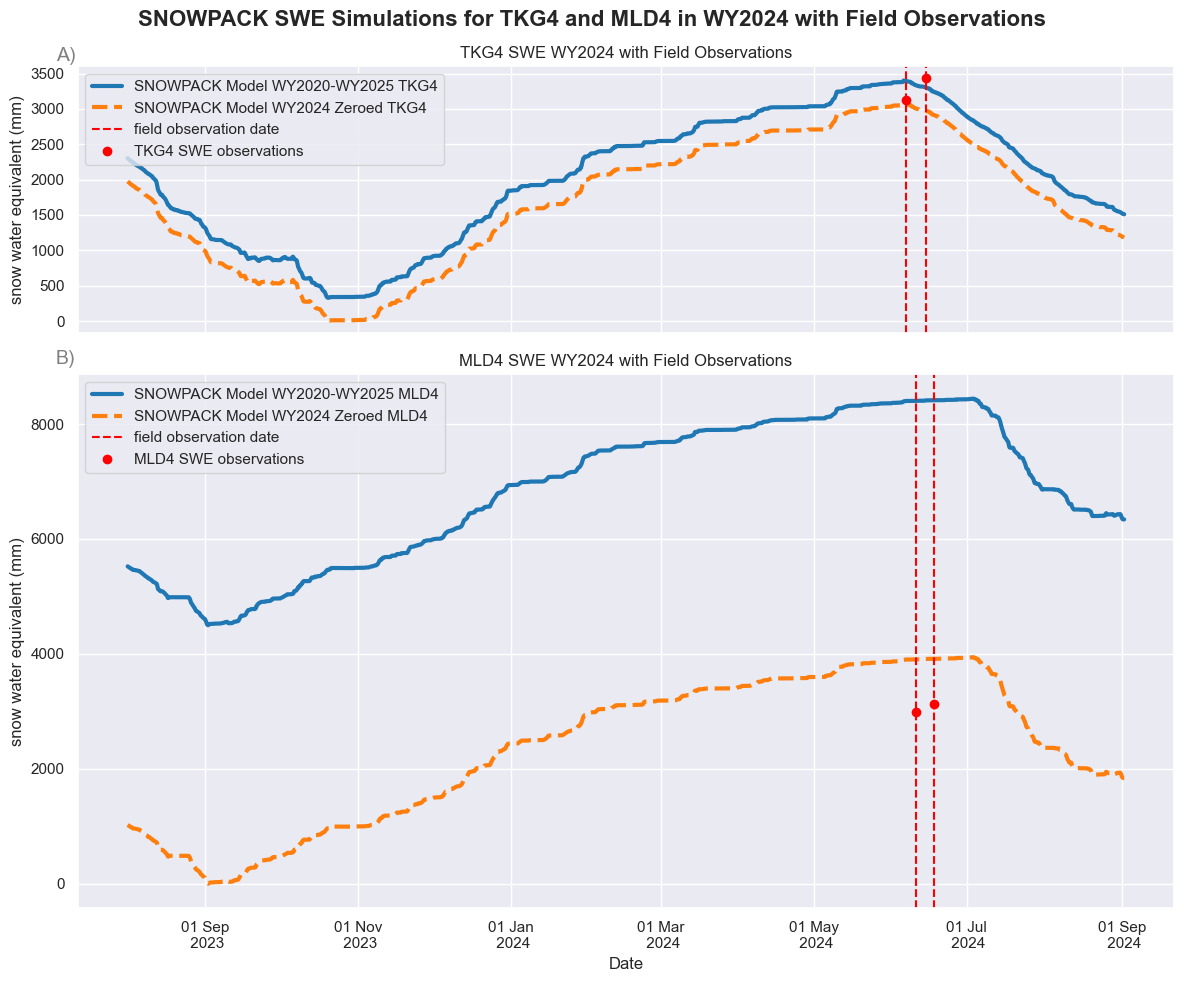

In [27]:
# combined subplot of SWE for TKG4 (top) and MLD4 (bottom) for WY2024
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

# top: TKG4 SWE
swe_tkg4 = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_tkg4.plot(ax=axes[0], label='SNOWPACK Model WY2020-WY2025 TKG4', linewidth=3, color='tab:blue')

swe_tkg4_zeroed = swe_tkg4 - swe_tkg4.min(dim='timestamp')
swe_tkg4_zeroed.plot(ax=axes[0], label='SNOWPACK Model WY2024 Zeroed TKG4', linewidth=3, color='tab:orange', linestyle='--')

axes[0].axvline(df_field_swe_tkg4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[0].axvline(df_field_swe_tkg4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[0].plot(df_field_swe_tkg4['date'], df_field_swe_tkg4['swe_mm'], marker='o', color='red', linestyle='', label='TKG4 SWE observations')

axes[0].legend(loc='upper left')
axes[0].set_title('TKG4 SWE WY2024 with Field Observations')
axes[0].set_ylabel('snow water equivalent (mm)')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))

# bottom: MLD4 SWE
swe_mld4 = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
swe_mld4.plot(ax=axes[1], label='SNOWPACK Model WY2020-WY2025 MLD4', linewidth=3, color='tab:blue')

swe_mld4_zeroed = swe_mld4 - swe_mld4.min(dim='timestamp')
swe_mld4_zeroed.plot(ax=axes[1], label='SNOWPACK Model WY2024 Zeroed MLD4', linewidth=3, color='tab:orange', linestyle='--')

axes[1].axvline(df_field_swe_mld4['date'].iloc[0], color='red', linestyle='--', label='field observation date')
axes[1].axvline(df_field_swe_mld4['date'].iloc[1], color='red', linestyle='--', label=None)
axes[1].plot(df_field_swe_mld4['date'], df_field_swe_mld4['swe_mm'], marker='o', color='red', linestyle='', label='MLD4 SWE observations')

# highlight the MLD4 axes[1] region covered by the TKG4 SWE top plot
# y0_min, y0_max = axes[0].get_ylim()
# axes[1].axhspan(y0_min, y0_max, color='grey', alpha=0.5)

axes[1].legend(loc='upper left')
axes[1].set_title('MLD4 SWE WY2024 with Field Observations')
axes[1].set_ylabel('snow water equivalent (mm)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%d %b\n %Y'))
for label in axes[1].get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment('center')
    
# add an A) and B) label to the top left of each subplot
axes[0].text(-0.02, 1.02, 'A)', transform=axes[0].transAxes, color = 'grey', fontsize=14) #, fontweight='bold')
axes[1].text(-0.02, 1.02, 'B)', transform=axes[1].transAxes, color = 'grey', fontsize=14) #, fontweight='bold')

plt.suptitle('SNOWPACK SWE Simulations for TKG4 and MLD4 in WY2024 with Field Observations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Numbers 

In [28]:
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_tkg4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0]:
    obs_date = df_field_depth_tkg4['date'].iloc[i]
    field_depth = df_field_depth_tkg4['core_depth_cm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field core depth: {field_depth:.2f} cm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} cm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} cm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')
    
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_tkg4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_swe_tkg4['date'].iloc[i]
    field_depth = df_field_swe_tkg4['swe_mm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field SWE: {field_depth:.2f} mm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} mm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} mm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')


Observation 1 date: 2024-06-15
  Field core depth: 642.50 cm
  Blue WY2024 model value: 625.82 cm
  Orange WY2024 zeroed model value: 567.98 cm
  Percent difference (orange vs field): -11.6%

Observation 1 date: 2024-06-07
  Field SWE: 3130.00 mm
  Blue WY2024 model value: 3392.11 mm
  Orange WY2024 zeroed model value: 3063.59 mm
  Percent difference (orange vs field): -2.1%

Observation 2 date: 2024-06-15
  Field SWE: 3430.00 mm
  Blue WY2024 model value: 3297.23 mm
  Orange WY2024 zeroed model value: 2968.71 mm
  Percent difference (orange vs field): -13.4%



In [29]:
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_mld4.HS_mod.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_depth_mld4['date'].iloc[i]
    field_depth = df_field_depth_mld4['core_depth_cm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field core depth: {field_depth:.2f} cm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} cm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} cm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')
    
# print the field observation values and the corresponding model values for the two plotted lines
hs_model_ds = ds_snowpack_mld4.SWE.sel(timestamp=slice('2023-08-01', '2024-09-01')).copy(deep=True)
hs_model_zeroed = hs_model_ds - hs_model_ds.min(dim='timestamp')

for i in [0, 1]:
    obs_date = df_field_swe_mld4['date'].iloc[i]
    field_depth = df_field_swe_mld4['swe_mm'].iloc[i]
    blue_value = hs_model_ds.sel(timestamp=obs_date, method='nearest').values.item()
    orange_value = hs_model_zeroed.sel(timestamp=obs_date, method='nearest').values.item()
    percent_diff = ((orange_value - field_depth) / field_depth) * 100
    print(f"Observation {i+1} date: {obs_date:%Y-%m-%d}")
    print(f"  Field SWE: {field_depth:.2f} mm")
    print(f"  Blue WY2024 model value: {blue_value:.2f} mm")
    print(f"  Orange WY2024 zeroed model value: {orange_value:.2f} mm")
    print(f"  Percent difference (orange vs field): {percent_diff:.1f}%")
    print('')


Observation 1 date: 2024-06-11
  Field core depth: 678.50 cm
  Blue WY2024 model value: 1641.72 cm
  Orange WY2024 zeroed model value: 911.36 cm
  Percent difference (orange vs field): 34.3%

Observation 2 date: 2024-06-18
  Field core depth: 657.00 cm
  Blue WY2024 model value: 1630.70 cm
  Orange WY2024 zeroed model value: 900.34 cm
  Percent difference (orange vs field): 37.0%

Observation 1 date: 2024-06-11
  Field SWE: 2990.00 mm
  Blue WY2024 model value: 8403.09 mm
  Orange WY2024 zeroed model value: 3904.25 mm
  Percent difference (orange vs field): 30.6%

Observation 2 date: 2024-06-18
  Field SWE: 3130.00 mm
  Blue WY2024 model value: 8413.65 mm
  Orange WY2024 zeroed model value: 3914.81 mm
  Percent difference (orange vs field): 25.1%



# Quarterly Report Figure Sept 2026

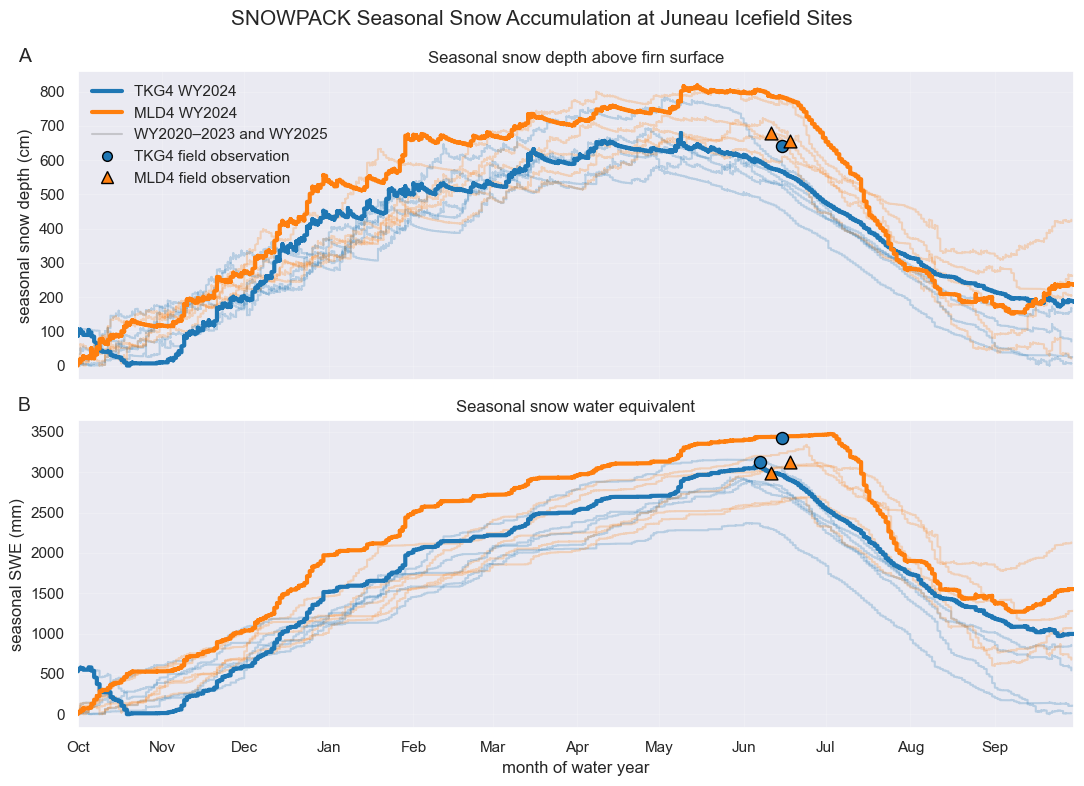

In [33]:
# ============================================================
# Quarterly report figure:
# A) Seasonal snow depth above firn surface
# B) Seasonal SWE above firn surface
#
# Overlays WY2020-WY2025 on a common Oct-Sep water-year axis.
# WY2024 is highlighted because field observations are available.
#
# Assumes:
#   ds_snowpack_tkg4 contains variables HS_mod and SWE
#   ds_snowpack_mld4 contains variables HS_mod and SWE
#
# Field observation dataframes assumed:
#   df_field_depth_tkg4
#   df_field_depth_mld4
#   df_field_swe_tkg4
#   df_field_swe_mld4
#
# Update the snow-depth observation column name below if needed.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Functions
# ------------------------------------------------------------

def get_zeroed_wy(ds, variable, wy):
    """
    Extract one water year (Oct 1 - Sep 30) and reference the
    variable to its minimum value during that water year.

    This gives seasonal accumulation above the residual firn layer.
    """

    start = f'{wy-1}-10-01'
    end = f'{wy}-09-30'

    da = ds[variable].sel(timestamp=slice(start, end)).copy(deep=True)

    # Remove residual firn contribution / reference to annual minimum
    da_zeroed = da - da.min(dim='timestamp')

    return da_zeroed


def water_year_day_axis(da):
    """
    Convert timestamps to day of water year:
    Oct 1 = day 0.
    """

    dates = pd.DatetimeIndex(da.timestamp.values)

    start_year = np.where(
        dates.month >= 10,
        dates.year,
        dates.year - 1
    )

    wy_start = pd.to_datetime(
        [f'{year}-10-01' for year in start_year]
    )

    return (dates - wy_start).days


def dates_to_wy_day(dates):
    """
    Convert observation dates to day of water year:
    Oct 1 = day 0.
    """

    dates = pd.DatetimeIndex(pd.to_datetime(dates))

    start_year = np.where(
        dates.month >= 10,
        dates.year,
        dates.year - 1
    )

    wy_start = pd.to_datetime(
        [f'{year}-10-01' for year in start_year]
    )

    return (dates - wy_start).days


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

water_years = range(2020, 2026)

color_tkg4 = 'tab:blue'
color_mld4 = 'tab:orange'

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 8),
    sharex=True
)


# ============================================================
# A) SEASONAL SNOW DEPTH ABOVE FIRN
# ============================================================

ax = axes[0]

for wy in water_years:

    hs_tkg4 = get_zeroed_wy(
        ds_snowpack_tkg4,
        'HS_mod',
        wy
    )

    hs_mld4 = get_zeroed_wy(
        ds_snowpack_mld4,
        'HS_mod',
        wy
    )

    x_tkg4 = water_year_day_axis(hs_tkg4)
    x_mld4 = water_year_day_axis(hs_mld4)

    # Highlight WY2024
    if wy == 2024:
        alpha = 1.0
        linewidth = 3.0
        zorder = 3
    else:
        alpha = 0.25
        linewidth = 1.5
        zorder = 1

    ax.plot(
        x_tkg4,
        hs_tkg4.values,
        color=color_tkg4,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder
    )

    ax.plot(
        x_mld4,
        hs_mld4.values,
        color=color_mld4,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder
    )


# ------------------------------------------------------------
# Snow-depth observations
#
# IMPORTANT:
# Change 'core_depth_cm' below if your dataframe uses a
# different column name.
# ------------------------------------------------------------

x_obs_tkg4_hs = dates_to_wy_day(
    df_field_depth_tkg4['date']
)

axes[0].scatter(
    x_obs_tkg4_hs,
    df_field_depth_tkg4['core_depth_cm'],
    color=color_tkg4,
    edgecolor='black',
    s=75,
    zorder=5
)


x_obs_mld4_hs = dates_to_wy_day(
    df_field_depth_mld4['date']
)

axes[0].scatter(
    x_obs_mld4_hs,
    df_field_depth_mld4['core_depth_cm'],
    color=color_mld4,
    edgecolor='black',
    marker='^',
    s=85,
    zorder=5
)


# ============================================================
# B) SEASONAL SWE ABOVE FIRN
# ============================================================

ax = axes[1]

for wy in water_years:

    swe_tkg4 = get_zeroed_wy(
        ds_snowpack_tkg4,
        'SWE',
        wy
    )

    swe_mld4 = get_zeroed_wy(
        ds_snowpack_mld4,
        'SWE',
        wy
    )

    x_tkg4 = water_year_day_axis(swe_tkg4)
    x_mld4 = water_year_day_axis(swe_mld4)

    # Highlight WY2024
    if wy == 2024:
        alpha = 1.0
        linewidth = 3.0
        zorder = 3
    else:
        alpha = 0.25
        linewidth = 1.5
        zorder = 1

    ax.plot(
        x_tkg4,
        swe_tkg4.values,
        color=color_tkg4,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder
    )

    ax.plot(
        x_mld4,
        swe_mld4.values,
        color=color_mld4,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder
    )


# ------------------------------------------------------------
# SWE observations
# ------------------------------------------------------------

x_obs_tkg4_swe = dates_to_wy_day(
    df_field_swe_tkg4['date']
)

axes[1].scatter(
    x_obs_tkg4_swe,
    df_field_swe_tkg4['swe_mm'],
    color=color_tkg4,
    edgecolor='black',
    s=75,
    zorder=5
)


x_obs_mld4_swe = dates_to_wy_day(
    df_field_swe_mld4['date']
)

axes[1].scatter(
    x_obs_mld4_swe,
    df_field_swe_mld4['swe_mm'],
    color=color_mld4,
    edgecolor='black',
    marker='^',
    s=85,
    zorder=5
)


# ============================================================
# Axis formatting
# ============================================================

# Common Oct-Sep month axis
month_dates = pd.date_range(
    '2023-10-01',
    '2024-09-01',
    freq='MS'
)

month_days = (
    month_dates - pd.Timestamp('2023-10-01')
).days

month_labels = [
    'Oct', 'Nov', 'Dec',
    'Jan', 'Feb', 'Mar',
    'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep'
]

axes[1].set_xticks(month_days)
axes[1].set_xticklabels(month_labels)

axes[0].set_xlim(0, 365)


# ------------------------------------------------------------
# Labels and titles
# ------------------------------------------------------------

axes[0].set_ylabel('seasonal snow depth (cm)')
axes[1].set_ylabel('seasonal SWE (mm)')
axes[1].set_xlabel('month of water year')

axes[0].set_title(
    'Seasonal snow depth above firn surface'
)

axes[1].set_title(
    'Seasonal snow water equivalent'
)


# ------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------

axes[0].text(
    -0.06,
    1.03,
    'A',
    transform=axes[0].transAxes,
    fontsize=14
)

axes[1].text(
    -0.06,
    1.03,
    'B',
    transform=axes[1].transAxes,
    fontsize=14
)


# ============================================================
# Custom legend
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        color=color_tkg4,
        lw=3,
        label='TKG4 WY2024'
    ),

    Line2D(
        [0], [0],
        color=color_mld4,
        lw=3,
        label='MLD4 WY2024'
    ),

    Line2D(
        [0], [0],
        color='grey',
        lw=1.5,
        alpha=0.35,
        label='WY2020–2023 and WY2025'
    ),

    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=color_tkg4,
        markeredgecolor='black',
        markersize=7,
        label='TKG4 field observation'
    ),

    Line2D(
        [0], [0],
        marker='^',
        linestyle='',
        markerfacecolor=color_mld4,
        markeredgecolor='black',
        markersize=8,
        label='MLD4 field observation'
    )
]

axes[0].legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False
)


# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------

for ax in axes:
    ax.grid(alpha=0.2)

plt.suptitle(
    'SNOWPACK Seasonal Snow Accumulation at Juneau Icefield Sites',
    fontsize=15
)

plt.tight_layout()

plt.show()

Fixing the datetime to be all years, 

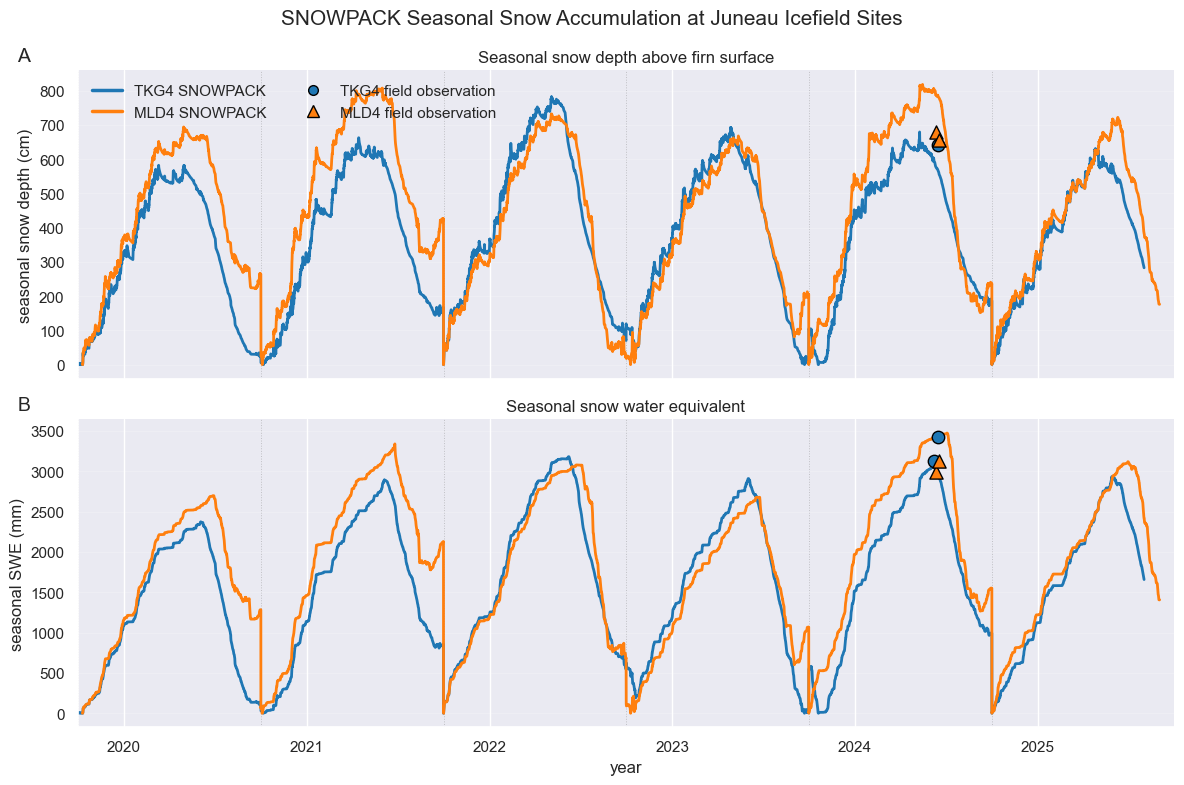

In [34]:
# ============================================================
# Quarterly report figure
#
# A) Seasonal snow depth above firn surface
# B) Seasonal SWE above firn surface
#
# Continuous chronological time series from WY2020-WY2025
# for TKG4 and MLD4.
#
# Each water year is independently referenced to its minimum
# value so that the plotted quantity represents seasonal
# accumulation above the residual firn surface.
#
# Field observations are plotted on their actual observation dates.
#
# Assumes:
#   ds_snowpack_tkg4 contains variables HS_mod and SWE
#   ds_snowpack_mld4 contains variables HS_mod and SWE
#
# Field observation dataframes:
#   df_field_depth_tkg4
#   df_field_depth_mld4
#   df_field_swe_tkg4
#   df_field_swe_mld4
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Function: create seasonally referenced continuous time series
# ------------------------------------------------------------

def get_zeroed_timeseries(ds, variable, water_years):
    """
    Extract and zero each water year independently, while retaining
    the original datetime coordinates.

    Each water year runs Oct 1 through Sep 30.

    The annual minimum is subtracted from that year's values,
    representing seasonal accumulation above the residual firn layer.
    """

    zeroed_years = []

    for wy in water_years:

        start = f'{wy-1}-10-01'
        end   = f'{wy}-09-30 23:59:59'

        da = ds[variable].sel(
            timestamp=slice(start, end)
        ).copy(deep=True)

        if da.size == 0:
            continue

        da_zeroed = da - da.min(dim='timestamp')

        zeroed_years.append(da_zeroed)

    # Combine water years back into one chronological time series
    da_all = xr.concat(zeroed_years, dim='timestamp')

    return da_all.sortby('timestamp')


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

water_years = range(2020, 2026)

color_tkg4 = 'tab:blue'
color_mld4 = 'tab:orange'

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


# ============================================================
# Create continuous zeroed model time series
# ============================================================

# Snow depth
hs_tkg4_zeroed = get_zeroed_timeseries(
    ds_snowpack_tkg4,
    'HS_mod',
    water_years
)

hs_mld4_zeroed = get_zeroed_timeseries(
    ds_snowpack_mld4,
    'HS_mod',
    water_years
)

# SWE
swe_tkg4_zeroed = get_zeroed_timeseries(
    ds_snowpack_tkg4,
    'SWE',
    water_years
)

swe_mld4_zeroed = get_zeroed_timeseries(
    ds_snowpack_mld4,
    'SWE',
    water_years
)


# ============================================================
# A) SEASONAL SNOW DEPTH ABOVE FIRN
# ============================================================

axes[0].plot(
    hs_tkg4_zeroed.timestamp,
    hs_tkg4_zeroed,
    color=color_tkg4,
    linewidth=2,
    label='TKG4'
)

axes[0].plot(
    hs_mld4_zeroed.timestamp,
    hs_mld4_zeroed,
    color=color_mld4,
    linewidth=2,
    label='MLD4'
)


# ------------------------------------------------------------
# Snow-firn transition depth observations
# ------------------------------------------------------------

axes[0].scatter(
    pd.to_datetime(df_field_depth_tkg4['date']),
    df_field_depth_tkg4['core_depth_cm'],
    color=color_tkg4,
    edgecolor='black',
    marker='o',
    s=80,
    zorder=5,
    label='TKG4 field observation'
)

axes[0].scatter(
    pd.to_datetime(df_field_depth_mld4['date']),
    df_field_depth_mld4['core_depth_cm'],
    color=color_mld4,
    edgecolor='black',
    marker='^',
    s=90,
    zorder=5,
    label='MLD4 field observation'
)


# ============================================================
# B) SEASONAL SWE ABOVE FIRN
# ============================================================

axes[1].plot(
    swe_tkg4_zeroed.timestamp,
    swe_tkg4_zeroed,
    color=color_tkg4,
    linewidth=2,
    label='TKG4'
)

axes[1].plot(
    swe_mld4_zeroed.timestamp,
    swe_mld4_zeroed,
    color=color_mld4,
    linewidth=2,
    label='MLD4'
)


# ------------------------------------------------------------
# SWE observations
# ------------------------------------------------------------

axes[1].scatter(
    pd.to_datetime(df_field_swe_tkg4['date']),
    df_field_swe_tkg4['swe_mm'],
    color=color_tkg4,
    edgecolor='black',
    marker='o',
    s=80,
    zorder=5
)

axes[1].scatter(
    pd.to_datetime(df_field_swe_mld4['date']),
    df_field_swe_mld4['swe_mm'],
    color=color_mld4,
    edgecolor='black',
    marker='^',
    s=90,
    zorder=5
)


# ============================================================
# Formatting
# ============================================================

# Panel titles
axes[0].set_title(
    'Seasonal snow depth above firn surface'
)

axes[1].set_title(
    'Seasonal snow water equivalent'
)

# Axis labels
axes[0].set_ylabel(
    'seasonal snow depth (cm)'
)

axes[1].set_ylabel(
    'seasonal SWE (mm)'
)

axes[1].set_xlabel(
    'year'
)


# ------------------------------------------------------------
# Panel labels
# ------------------------------------------------------------

axes[0].text(
    -0.055,
    1.03,
    'A',
    transform=axes[0].transAxes,
    fontsize=14
)

axes[1].text(
    -0.055,
    1.03,
    'B',
    transform=axes[1].transAxes,
    fontsize=14
)


# ------------------------------------------------------------
# X-axis formatting
# ------------------------------------------------------------

# Major tick every year
axes[1].xaxis.set_major_locator(
    mdates.YearLocator()
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

# Optional minor ticks every 3 months
axes[1].xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

# Limit to model period
axes[1].set_xlim(
    pd.Timestamp('2019-10-01'),
    pd.Timestamp('2025-09-30')
)


# ------------------------------------------------------------
# Water-year boundaries
# ------------------------------------------------------------

# Light vertical lines at October 1 to make individual
# water years easier to see
for wy in water_years:

    wy_start = pd.Timestamp(f'{wy-1}-10-01')

    for ax in axes:
        ax.axvline(
            wy_start,
            color='grey',
            linewidth=0.7,
            linestyle=':',
            alpha=0.4,
            zorder=0
        )


# ============================================================
# Custom legend
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        color=color_tkg4,
        lw=2.5,
        label='TKG4 SNOWPACK'
    ),

    Line2D(
        [0], [0],
        color=color_mld4,
        lw=2.5,
        label='MLD4 SNOWPACK'
    ),

    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=color_tkg4,
        markeredgecolor='black',
        markersize=7,
        label='TKG4 field observation'
    ),

    Line2D(
        [0], [0],
        marker='^',
        linestyle='',
        markerfacecolor=color_mld4,
        markeredgecolor='black',
        markersize=8,
        label='MLD4 field observation'
    )
]

axes[0].legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False,
    ncol=2
)


# ------------------------------------------------------------
# Grid / overall formatting
# ------------------------------------------------------------

for ax in axes:

    ax.grid(
        axis='y',
        alpha=0.2
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.suptitle(
    'SNOWPACK Seasonal Snow Accumulation at Juneau Icefield Sites',
    fontsize=15
)

plt.tight_layout()

plt.show()

WY2024 residual firn baselines:
TKG4 snow depth: 57.8 cm
MLD4 snow depth: 854.0 cm
TKG4 SWE:        328.5 mm
MLD4 SWE:        4966.2 mm


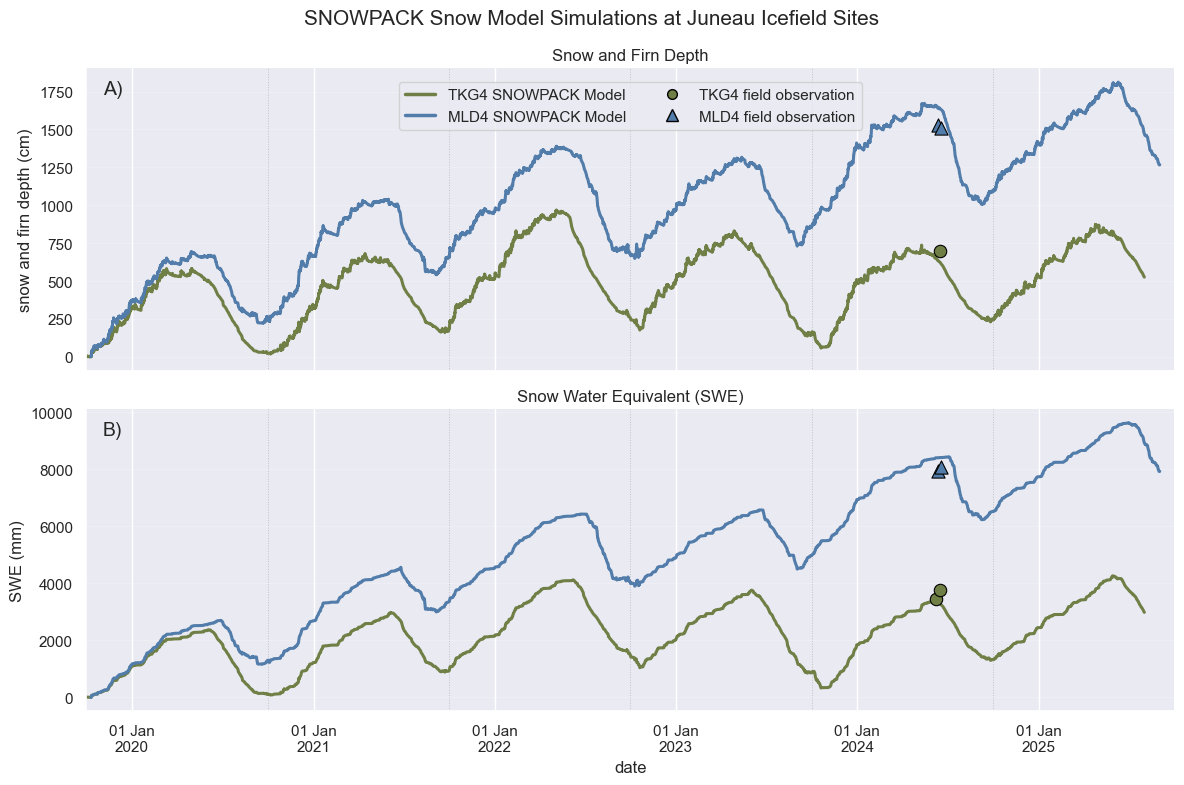

In [38]:
# ============================================================
# Quarterly report figure
#
# A) Total modeled snow/firn depth
# B) Total modeled Snow Water Equivalent (SWE)
#
# Continuous chronological SNOWPACK simulations from
# WY2020-WY2025 are plotted without zeroing.
#
# Field observations from WY2024 represent seasonal snow
# above the firn surface. Therefore, observations are shifted
# upward by the modeled residual firn amount (the minimum
# modeled value during WY2024) so that they are shown in the
# same reference frame as the continuous SNOWPACK simulation.
#
# Assumes:
#   ds_snowpack_tkg4 contains variables HS_mod and SWE
#   ds_snowpack_mld4 contains variables HS_mod and SWE
#
# Field observation dataframes:
#   df_field_depth_tkg4
#   df_field_depth_mld4
#   df_field_swe_tkg4
#   df_field_swe_mld4
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

start_date = '2019-10-01'
end_date   = '2025-09-30'

# WY2024 period used to determine residual firn baseline
wy2024_start = '2023-10-01'
wy2024_end   = '2024-09-30'

# Site colors
# TKG4 = lower elevation, muted olive green
# MLD4 = higher elevation, muted glacier blue
color_tkg4 = '#6F7F45'
color_mld4 = '#527DAA'


# ============================================================
# Extract full continuous model simulations
# ============================================================

# Snow/firn depth
hs_tkg4 = ds_snowpack_tkg4['HS_mod'].sel(
    timestamp=slice(start_date, end_date)
)

hs_mld4 = ds_snowpack_mld4['HS_mod'].sel(
    timestamp=slice(start_date, end_date)
)

# SWE
swe_tkg4 = ds_snowpack_tkg4['SWE'].sel(
    timestamp=slice(start_date, end_date)
)

swe_mld4 = ds_snowpack_mld4['SWE'].sel(
    timestamp=slice(start_date, end_date)
)


# ============================================================
# Calculate WY2024 residual firn baseline
#
# This is the value that was previously subtracted from the
# model to create the "zeroed" seasonal time series.
#
# Here, instead, we ADD it to the observations.
# ============================================================

# Snow depth residuals
hs_baseline_tkg4 = float(
    ds_snowpack_tkg4['HS_mod']
    .sel(timestamp=slice(wy2024_start, wy2024_end))
    .min()
)

hs_baseline_mld4 = float(
    ds_snowpack_mld4['HS_mod']
    .sel(timestamp=slice(wy2024_start, wy2024_end))
    .min()
)

# SWE residuals
swe_baseline_tkg4 = float(
    ds_snowpack_tkg4['SWE']
    .sel(timestamp=slice(wy2024_start, wy2024_end))
    .min()
)

swe_baseline_mld4 = float(
    ds_snowpack_mld4['SWE']
    .sel(timestamp=slice(wy2024_start, wy2024_end))
    .min()
)


# ------------------------------------------------------------
# Print baselines so values can be checked
# ------------------------------------------------------------

print('WY2024 residual firn baselines:')
print(f'TKG4 snow depth: {hs_baseline_tkg4:.1f} cm')
print(f'MLD4 snow depth: {hs_baseline_mld4:.1f} cm')
print(f'TKG4 SWE:        {swe_baseline_tkg4:.1f} mm')
print(f'MLD4 SWE:        {swe_baseline_mld4:.1f} mm')


# ============================================================
# Adjust field observations into the same reference frame
# as the continuous SNOWPACK simulations
# ============================================================

# Snow-firn transition depth
hs_obs_tkg4_adjusted = (
    df_field_depth_tkg4['core_depth_cm']
    + hs_baseline_tkg4
)

hs_obs_mld4_adjusted = (
    df_field_depth_mld4['core_depth_cm']
    + hs_baseline_mld4
)

# SWE
swe_obs_tkg4_adjusted = (
    df_field_swe_tkg4['swe_mm']
    + swe_baseline_tkg4
)

swe_obs_mld4_adjusted = (
    df_field_swe_mld4['swe_mm']
    + swe_baseline_mld4
)


# ============================================================
# Create figure
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True
)


# ============================================================
# A) TOTAL SNOW / FIRN DEPTH
# ============================================================

axes[0].plot(
    hs_tkg4.timestamp,
    hs_tkg4,
    color=color_tkg4,
    linewidth=2.2,
    label='TKG4'
)

axes[0].plot(
    hs_mld4.timestamp,
    hs_mld4,
    color=color_mld4,
    linewidth=2.2,
    label='MLD4'
)


# ------------------------------------------------------------
# Adjusted snow-depth observations
# ------------------------------------------------------------

axes[0].scatter(
    pd.to_datetime(df_field_depth_tkg4['date']),
    hs_obs_tkg4_adjusted,
    color=color_tkg4,
    edgecolor='black',
    linewidth=0.8,
    marker='o',
    s=80,
    zorder=5
)

axes[0].scatter(
    pd.to_datetime(df_field_depth_mld4['date']),
    hs_obs_mld4_adjusted,
    color=color_mld4,
    edgecolor='black',
    linewidth=0.8,
    marker='^',
    s=90,
    zorder=5
)


# ============================================================
# B) TOTAL SWE
# ============================================================

axes[1].plot(
    swe_tkg4.timestamp,
    swe_tkg4,
    color=color_tkg4,
    linewidth=2.2,
    label='TKG4'
)

axes[1].plot(
    swe_mld4.timestamp,
    swe_mld4,
    color=color_mld4,
    linewidth=2.2,
    label='MLD4'
)


# ------------------------------------------------------------
# Adjusted SWE observations
# ------------------------------------------------------------

axes[1].scatter(
    pd.to_datetime(df_field_swe_tkg4['date']),
    swe_obs_tkg4_adjusted,
    color=color_tkg4,
    edgecolor='black',
    linewidth=0.8,
    marker='o',
    s=80,
    zorder=5
)

axes[1].scatter(
    pd.to_datetime(df_field_swe_mld4['date']),
    swe_obs_mld4_adjusted,
    color=color_mld4,
    edgecolor='black',
    linewidth=0.8,
    marker='^',
    s=90,
    zorder=5
)


# ============================================================
# Labels and titles
# ============================================================

axes[0].set_title(
    'Snow and Firn Depth'
)

axes[1].set_title(
    'Snow Water Equivalent (SWE)'
)

axes[0].set_ylabel(
    'snow and firn depth (cm)'
)

axes[1].set_ylabel(
    'SWE (mm)'
)

axes[1].set_xlabel(
    'date'
)


# ============================================================
# Panel labels inside upper-left corners
# ============================================================

axes[0].text(
    0.015,
    0.96,
    'A)',
    transform=axes[0].transAxes,
    fontsize=14,
    verticalalignment='top',
    horizontalalignment='left'
)

axes[1].text(
    0.015,
    0.96,
    'B)',
    transform=axes[1].transAxes,
    fontsize=14,
    verticalalignment='top',
    horizontalalignment='left'
)


# ============================================================
# Date-axis formatting
# ============================================================

# Tick at January 1 of every year
axes[1].xaxis.set_major_locator(
    mdates.YearLocator()
)

# Display actual first day of each year
# Example:
# 01 Jan
# 2023
axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b\n%Y')
)

# Minor ticks every 3 months
axes[1].xaxis.set_minor_locator(
    mdates.MonthLocator(interval=3)
)

axes[1].set_xlim(
    pd.Timestamp(start_date),
    pd.Timestamp(end_date)
)


# ============================================================
# Water-year boundaries
# ============================================================

for year in range(2020, 2026):

    wy_start = pd.Timestamp(f'{year-1}-10-01')

    for ax in axes:
        ax.axvline(
            wy_start,
            color='grey',
            linewidth=0.7,
            linestyle=':',
            alpha=0.4,
            zorder=0
        )


# ============================================================
# Custom legend
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        color=color_tkg4,
        lw=2.5,
        label='TKG4 SNOWPACK Model'
    ),

    Line2D(
        [0], [0],
        color=color_mld4,
        lw=2.5,
        label='MLD4 SNOWPACK Model'
    ),

    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=color_tkg4,
        markeredgecolor='black',
        markersize=7,
        label='TKG4 field observation'
    ),

    Line2D(
        [0], [0],
        marker='^',
        linestyle='',
        markerfacecolor=color_mld4,
        markeredgecolor='black',
        markersize=8,
        label='MLD4 field observation'
    )
]

axes[0].legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    # frameon=True,
    # fancybox=False,
    # edgecolor='black',
    ncol=2
)


# ============================================================
# Final formatting
# ============================================================

for ax in axes:

    ax.grid(
        axis='y',
        alpha=0.2
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.suptitle(
    'SNOWPACK Snow Model Simulations at Juneau Icefield Sites',
    fontsize=15
)

plt.tight_layout()

plt.show()